In [11]:
!pip install pyne2001
!pip install pyvo
!pip install extinction
!pip install dustmaps
!pip install linetools
!pip install --ignore-installed --no-cache-dir astro-datalab --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 11.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyne2001: filename=pyne2001-0.1.3-py3-none-any.whl size=93704 sha256=bb5563ae1faba0403fd303396f0d08e7613b50b3fbae23ad8b822e006985ddee
  Stored in directory: /tmp/pip-ephem-wheel-cache-pgtfw_05/wheels/6b/a2/68/51e7e7b0a68b70e79a4f4479b9a81e95cc9a74daad2390aa53
Successfully built pyne2001
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.8/458.8 kB 18.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.6/750.6 kB 20.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 177.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.2/30.2 MB 11.8 MB/s eta 0:00:00 0:00:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.5/93.5 kB 228.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.9/202.9 kB 11.4 MB/s eta 0:00:00


In [1]:
from frb.surveys.decals import DECaL_Survey
from frb.surveys.panstarrs import Pan_STARRS_Survey

In [2]:

def get_ne2001(c_icrs,get_scatt = True):
    dm_ne2001 = np.zeros(len(c_icrs))
    tau600_ne2001 = np.zeros(len(c_icrs))

    for ii,(gl,gb) in enumerate(zip(c_icrs.galactic.l,c_icrs.galactic.b)):
        ne2001_pred = pyne2001.get_dm_full(gl.value,gb.value,dist_kpc = 100.0)
        #print(f"dist: {ne2001_pred['DIST']}")
        dm_ne2001[ii] = ne2001_pred['DM']
        tau600_ne2001[ii] = ne2001_pred['TAU'] * (1/0.6)**4
    if get_scatt:
        return dm_ne2001,tau600_ne2001
    else:
        return dm_ne2001
def calculate_halo_dm_yt20(l, b):
    coeffs = np.array(
        [
            [250.12, -871.06, 1877.5, -2553.0, 2181.3, -1127.5, 321.72, -38.905],
            [-154.82, 783.43, -1593.9, 1727.6, -1046.5, 332.09, -42.815, 0],
            [-116.72, -76.815, 428.49, -419.00, 174.60, -27.610, 0, 0],
            [216.67, -193.30, 12.234, 32.145, -8.3602, 0, 0, 0],
            [-129.95, 103.80, -22.800, 0.44171, 0, 0, 0, 0],
            [39.652, -21.398, 2.7694, 0, 0, 0, 0, 0],
            [-6.1926, 1.6162, 0, 0, 0, 0, 0, 0],
            [0.39346, 0, 0, 0, 0, 0, 0, 0],
        ]
    )
    l_absolute = np.abs(np.deg2rad(l))
    b_absolute = np.abs(np.deg2rad(b))
    DM_halo = 0
    for ii in range(8):
        for jj in range(8):
            DM_halo += coeffs[ii, jj] * l_absolute ** ii * b_absolute ** jj
    return DM_halo # u.pc / u.cm ** 3

In [37]:
import pandas

In [38]:
a  = pandas.read_csv('/arc/home/calvin/chime-ffff-pz/chime_ffff_pz/data/chime_frb_redshifts.csv')

In [39]:
for file in ['/arc/home/calvin/chime-ffff-pz/chime_ffff_pz/data/FRBs/chime_bright_first10.csv',
             '/arc/home/calvin/chime-ffff-pz/chime_ffff_pz/data/FRBs/chime_bright_first10.csv',
            '/arc/home/calvin/chime-ffff-pz/chime_ffff_pz/data/FRBs/chime_bright_jan_05.csv',
            '/arc/home/calvin/chime-ffff-pz/chime_ffff_pz/data/FRBs/chime_kko_feb2024.csv',
            '/arc/home/calvin/chime-ffff-pz/chime_ffff_pz/data/FRBs/chime_kko_nov2023.csv',
            '/arc/home/calvin/chime-ffff-pz/chime_ffff_pz/data/FRBs/chime_kko_sep2023.csv']:
    b = pandas.read_csv(file)
    print(b)

  frb_survey          tags          name  ra_err  dec_err     DM     a_err   
0  CHIME/FRB  CHIME-Bright  FRB20190125B      20       30  177.9  0.008333  \
1  CHIME/FRB  CHIME-Bright  FRB20190202B      44       52  464.8  0.014444   
2  CHIME/FRB  CHIME-Bright  FRB20190210D      25       42  359.3  0.011667   
3  CHIME/FRB  CHIME-Bright  FRB20191104B      56       63  192.2  0.017500   
4  CHIME/FRB  CHIME-Bright  FRB20191202A     136      415  117.9  0.115278   
5  CHIME/FRB  CHIME-Bright  FRB20191219E      45       80  736.7  0.022222   
6  CHIME/FRB  CHIME-Bright  FRB20201105A      57       58  262.4  0.016111   
7  CHIME/FRB  CHIME-Bright  FRB20201129A      29       48  274.6  0.013333   
8  CHIME/FRB  CHIME-Bright  FRB20210310B      32       39  135.5  0.010833   
9  CHIME/FRB  CHIME-Bright  FRB20210810A      17       20  246.9  0.005556   

      b_err  theta          ra        dec  
0  0.005556      0  217.450120  49.631878  
1  0.012222      0  105.580029  31.958580  
2  0.0069

# list of FRBs TNS names with event IDs by PATH probability

In [40]:
import numpy as np

import pandas as pd

from frb.surveys.panstarrs import Pan_STARRS_Survey
from frb.surveys.decals import DECaL_Survey
from astropy.coordinates import SkyCoord
from astropy import units as u


import glob

import astroquery

from astroquery.simbad import Simbad

import astropy.units as u

import astropy.coordinates as coord

In [79]:
final = pd.read_csv('/arc/home/calvin/kko_host_paper/data_products/KKO_bursts.csv',names = [
    'chime_event_id','TNS', 
    'DM','ra','dec',
    'wfall','Note','RM','pol_fraction',
    'Stokes_parameters_corrected',
    'fdf_clean', 'burst_profile', 
    'pol_pipeline_note','tau_scatt_ms',
    'tau_scatt_unc_ms', 'tau600_ne2001', 
    'fitburst_plot', 'fitburst_type', 
    'fitburst_note', 'P_Ox', 'hg_notes', 
    'redshift', 'simbad_link', 'redshift_info','hg_id','redshift_err',],
                   skiprows=1)
final.set_index('chime_event_id',inplace=True)

In [80]:
final

,TNS,DM,ra,dec,wfall,Note,RM,pol_fraction,Stokes_parameters_corrected,fdf_clean,...,fitburst_plot,fitburst_type,fitburst_note,P_Ox,hg_notes,redshift,simbad_link,redshift_info,hg_id,redshift_err
chime_event_id,,,,,,,,,,,,,,,,,,,,,
306528286,20230730A,312.5123,54.664430,33.159304,NaN,NaN,216.0425813,0.809,NaN,NaN,...,NaN,manual scint,FB done.,0.981888,NaN,0.211500,NaN,F4-z is 0.2115. zphot= 0.3192104 +- 0.16266767...,Pan-STARRS 147790546649113381,0.000100
272367619,20230222B,187.7517,238.738959,30.898700,NaN,NaN,Error,Error,NaN,NaN,...,NaN,"MCMC profile fit, dsamp 8, 5peaks",Done. Scattering ruled out.,0.982086,NaN,0.110000,https://www.legacysurvey.org/viewer?ra=238.738...,F4-z from Lick,DECaL 8796125887267257,0.000100
272350056,20230222A,706.0603,106.959922,11.224567,NaN,NaN,-72.96811398,0.235,NaN,NaN,...,NaN,scat high res,FB Done. Can fit for 2 peaks after decreasing ...,0.000000,NaN,0.122320,NaN,Lordrick-z is 0.12232,Pan-STARRS 121461069605007945,0.000100
275629567,20230311A,364.9632,91.111036,55.945893,NaN,NaN,-115.1793917,0.812,NaN,NaN,...,NaN,manual scint dsamp 8,FB done. Try scint without scattering. Maybe t...,0.975967,NaN,0.191800,NaN,Keck: 0.1918,Pan-STARRS 175130911105314689,0.000100
300938875,20230703A,291.2725,184.624341,48.729959,NaN,NaN,29.58312651,1.115,NaN,NaN,...,NaN,"MCMC profile fit, dsamp 8, 6peaks",Done. Scattering ruled out. Take 2*smallest bu...,0.990829,NaN,0.118400,NaN,z = 0.098: DESI DR9 photo-z; It is a real gala...,DECaL 8797230522435146,0.000100
268786306,20230203A,420.0500,151.662905,35.694009,NaN,NaN,-115.2441841,0.998,NaN,NaN,...,NaN,scat high res,FB Done. If its an exponentially increasing bu...,0.992672,NaN,0.146400,NaN,Lordrick-z,DECaL 8797226880009355,0.000100
326456063,20231011A,186.2933,18.241101,41.749098,NaN,NaN,-192.8313068,0.667,NaN,NaN,...,NaN,NaN,NaN,0.995596,NaN,0.078300,NaN,Keck: 0.0783,Pan-STARRS 158090182417819186,0.000100
341758878,20231202A,437.1000,65.030388,38.633278,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.993362,NaN,NaN,NaN,Could not get zphot from Pan-STARRS. F4PZ says...,Pan-STARRS 154360650307570235,NaN
341477821,20231201A,169.4000,54.589294,26.817672,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.946022,NaN,0.175831,NaN,zphot= 0.17583069 +- 0.0186939412537729 PS1_ST...,Pan-STARRS 140170545876545920,0.018000


In [81]:
import matplotlib.pyplot as plt

In [82]:
dsa_110_frbs = pd.read_csv('/arc/home/calvin/kko_host_paper/data_products/dsa_110_published.csv',
    names= ['Internal Name','MJD', 'DM','Width','SNR','ra','dec','poserr','Name','Redshift'],
                           skiprows = 1)

In [83]:
coord_dsa = coord.SkyCoord(dsa_110_frbs['ra'].values,dsa_110_frbs['dec'].values,unit = 'deg')

In [84]:
import pyne2001

In [85]:
get_ne2001(coord_dsa)

(array([139.7375,  54.6831,  55.6079,  76.0997, 128.2243,  46.3394,
         36.6542,  84.5563,  78.4804,  39.8597,  54.346 ]),
 array([0.03468364, 0.00239352, 0.00250386, 0.00512731, 0.02173611,
        0.00146991, 0.00091358, 0.00654244, 0.00551157, 0.00113117,
        0.00237191]))

In [86]:
dsa_110_frbs

,Internal Name,MJD,DM,Width,SNR,ra,dec,poserr,Name,Redshift
0,220319aaeb,59657.932757,110.950000,0.160000,79.00000,32.177917,71.035000,0.600,FRB 20220319D or Mark,0.011228
1,220914aabz,59836.145966,630.703000,0.524288,9.64463,282.056792,73.336914,0.930,FRB 20220914A or Elektra,0.113900
2,220426aaaw,59708.494499,270.260000,0.524288,21.50750,282.670000,70.243833,2.200,FRB 20220509G or Jackie,0.089400
3,220207aabh,59617.808504,263.000000,0.524288,59.96350,310.199525,72.882327,0.630,FRB 20220207C or Zach,0.043040
4,220307aaae,59645.845634,499.328000,0.524288,11.90590,350.874496,72.192386,1.720,FRB 20220307B or Alex,0.248123
5,220310aaam,59648.241721,462.657000,1.048576,68.41000,134.720500,73.490833,1.900,FRB 20220310F or Whitney,0.477958
6,220418aaai,59687.355728,624.124000,1.048576,10.87820,219.105575,70.095944,1.356,FRB 20220418A or Quincy,0.622000
7,220506aabd,59705.597013,396.651000,0.524288,48.91870,318.044833,72.827278,1.110,FRB 20220506D or Oran,0.300390
8,220825aaad,59816.257292,649.893000,1.048576,15.06450,311.981450,72.584969,0.780,FRB 20220825A or Ansel,0.241397
9,220920aacl,59842.981571,314.976978,0.524288,14.35070,240.257083,70.918800,1.020,FRB 20220920A or Etienne,0.158239


In [87]:
import pyne2001

In [88]:
c_icrs = SkyCoord(ra=final['ra'].values,
                  dec=final['dec'].values,unit = 'deg',frame = 'icrs') # baseband position

dm_ne2001, tau600_ne2001 = get_ne2001(c_icrs,get_scatt = True)
dm_yt20 = calculate_halo_dm_yt20(l = c_icrs.galactic.l.deg, b= c_icrs.galactic.b.deg)

In [89]:
final.insert(loc = 5, column = 'DM_NE2001',value = dm_ne2001,allow_duplicates = False)
final['NE2001 scattering time @ 600MHz'] = tau600_ne2001
final.insert(loc = 5, column = 'DM_YT20',value = dm_yt20,allow_duplicates = False)
final.insert(loc = 5, column = 'gal_l', value = c_icrs.galactic.l.deg)
final.insert(loc = 5, column = 'gal_b', value = c_icrs.galactic.b.deg)

In [90]:
from astropy.coordinates import SkyCoord

In [91]:
gal_lf = pd.read_csv('/arc/home/calvin/FRB/frb/data/Galaxies/galLF_vs_z.txt',sep='\t')

In [92]:
gal_lf

,z,m_r(L*),m_r(0.1L*),m_r(0.01L*)
0,0.020000,14.3354,16.8354,19.3354
1,0.050000,15.3354,17.8354,20.3354
2,0.089899,17.3708,19.8708,22.3708
3,0.129798,18.3882,20.8882,23.3882
4,0.169697,18.9821,21.4821,23.9821
...,...,...,...,...
96,3.840400,25.2699,27.7699,30.2699
97,3.880300,25.2877,27.7877,30.2877
98,3.920200,25.3052,27.8052,30.3052
99,3.960100,25.3226,27.8226,30.3226


In [93]:
def max_z_attainable(source_table,survey_depth,sigmas = 5,
                     dwarf_mag = -17, # R1 r' band from Tendulkar 2017, 
                     subtract_ne2001 = 0.8, 
                     subtract_halo = 30,
                     verbose = False
                     ):
    def dm_mw(coords):
        dm_mw_arr = []
        for c_icrs in coords:
            gl = c_icrs.galactic.l.value
            gb = c_icrs.galactic.b.value
            #print(f'For ra,dec = {c_icrs.ra.deg,c_icrs.dec.deg} <--> gl,gb={gl,gb}:')
            ne2001_pred = pyne2001.get_dm_full(gl,gb,dist_kpc = 100.0)
            #print(f"dist: {ne2001_pred['DIST']}")
            #print(f"dm  : {ne2001_pred['DM']}")
            #print(f"tau : {ne2001_pred['TAU']} ms @ 1 GHz")
            #print(f"tau : {ne2001_pred['TAU'] * (1000 / 600)**4.4} ms @ 0.6 GHz")
            dm_mw_arr.append(ne2001_pred['DM'])
        return np.array(dm_mw_arr)

    def max_z_from_dm(sources,dm_tots,factor = 1,halo = 0):
        assert len(sources) == len(dm_tots), "Wrong number of sources or DMs"
        dm_mws = np.array(dm_mw(sources)) * factor # allow 20% error on NE2001
        dm_sub = np.array(dm_tots) - dm_mws
        zmax = dm_sub / 985
        print(f'Extragalactic DM of {dm_sub} implies zmax = {zmax}')
        return zmax

    sources = coord.SkyCoord(source_table['ra'],source_table['dec'],unit = 'deg',frame = 'icrs')
    dm_tots = source_table['DM']
    n_src = len(sources)
    sfd = SFDQuery()
    e_b_minus_v = sfd(sources)
    r_v = 3.1
    a_v = r_v * e_b_minus_v
    # in SDSS R-band, as used by Shriharsh, the passband is centered at 0.625um -> x = 1.600. 
    # We want A(R), and A(lambda) / A(V) is provided using Table 3 from the OG Cardelli 1989 paper.
    # https://articles.adsabs.harvard.edu/pdf/1989ApJ...345..245C
    a_r_over_a_v = 1 + (0.751 - 1) * (1.6 - 1.82) / (1.43 - 1.82) # linear interpolation: y - y0 = (x - x0) * (y1 - y0) / (x1 - x0)
    a_r = a_r_over_a_v * a_v
    lum_dist_pc = 10 * 10**((survey_depth - dwarf_mag - a_r) / 5) # luminosity distances in parsecs
    redshift_grid = np.linspace(0,1,num = 300)
    from astropy.cosmology import WMAP9
    lum_dists = WMAP9.luminosity_distance(redshift_grid).to(u.pc).value
    if verbose: print(lum_dist_pc)
    z_limits = []
    v_limits = []
    z_maxs = max_z_from_dm(sources,dm_tots,factor = subtract_ne2001, halo = subtract_halo)
    v_maxs = WMAP9.comoving_volume(z_maxs).to(u.Mpc**3).value
    for ii in range(n_src):
        idx_closest = np.argmin(np.abs(lum_dists - lum_dist_pc[ii]))
        z_limit = redshift_grid[idx_closest]
        if verbose: print(f'Limiting distance is {lum_dists[idx_closest] / 1e9:.3f} Gpc (z={z_limit})')
        if verbose: print(f'For a survey down to m_r = {survey_depth:.0f}, M_r = {dwarf_mag:.0f} host would show up for z < {z_limit}.')
        v_limit = WMAP9.comoving_volume(z_limit).to(u.Mpc**3).value
        z_limits.append(z_limit)
        v_limits.append(v_limit)
    return np.array(z_limits),z_maxs,np.array(v_limits),v_maxs


In [94]:
%matplotlib inline

In [95]:
from astropy import units as u

(array([4., 5., 1., 1., 2., 0., 0., 0., 0., 1.]),
 array([0.0639 , 0.09391, 0.12392, 0.15393, 0.18394, 0.21395, 0.24396,
        0.27397, 0.30398, 0.33399, 0.364  ]),
 <BarContainer object of 10 artists>)

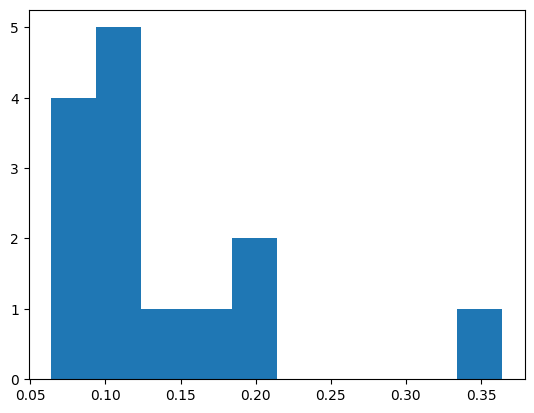

In [113]:
plt.figure()
plt.hist(final['redshift'][final['P_Ox'] > 0.90],density = False)

In [115]:
from dustmaps.sfd import SFDQuery
import dustmaps.sfd
dustmaps.sfd.fetch()

zl,zm,vl,vm = max_z_attainable(final,survey_depth = 23,sigmas = 5,dwarf_mag = -17,subtract_ne2001 = 1.0,subtract_halo = 30)

 63.2 MiB of 64.0 MiB |  30.4 MiB/s |################## |  98% | ETA:   0:00:000

 62.4 MiB of 64.0 MiB |  27.8 MiB/s |################## |  97% | ETA:   0:00:000

Extragalactic DM of [227.3565 160.0188 571.8588 272.5104 264.3449 383.7878 115.9431 294.3756
  99.4479 212.3514 320.0312  95.0623 890.0733 155.3296 307.3937 192.1713
 131.6741  69.8444 322.0618 549.7676 369.725 ] implies zmax = [0.23081878 0.16245563 0.58056731 0.2766603  0.26837046 0.38963228
 0.11770873 0.29885848 0.10096234 0.21558518 0.32490477 0.09650995
 0.90362772 0.15769503 0.31207482 0.19509777 0.13367929 0.07090802
 0.32696629 0.5581397  0.37535533]


In [116]:
final

,TNS,DM,ra,dec,wfall,gal_b,gal_l,DM_YT20,DM_NE2001,Note,...,fitburst_type,fitburst_note,P_Ox,hg_notes,redshift,simbad_link,redshift_info,hg_id,redshift_err,NE2001 scattering time @ 600MHz
chime_event_id,,,,,,,,,,,,,,,,,,,,,
306528286,20230730A,312.5123,54.664430,33.159304,NaN,-17.816513,158.816543,33.328343,85.1558,NaN,...,manual scint,FB done.,0.981888,NaN,0.211500,NaN,F4-z is 0.2115. zphot= 0.3192104 +- 0.16266767...,Pan-STARRS 147790546649113381,0.000100,0.006094
272367619,20230222B,187.7517,238.738959,30.898700,NaN,49.978858,49.617558,38.416755,27.7329,NaN,...,"MCMC profile fit, dsamp 8, 5peaks",Done. Scattering ruled out.,0.982086,NaN,0.110000,https://www.legacysurvey.org/viewer?ra=238.738...,F4-z from Lick,DECaL 8796125887267257,0.000100,0.000654
272350056,20230222A,706.0603,106.959922,11.224567,NaN,8.695371,204.716144,35.996803,134.2015,NaN,...,scat high res,FB Done. Can fit for 2 peaks after decreasing ...,0.000000,NaN,0.122320,NaN,Lordrick-z is 0.12232,Pan-STARRS 121461069605007945,0.000100,0.033194
275629567,20230311A,364.9632,91.111036,55.945893,NaN,16.040142,157.713769,33.863883,92.4528,NaN,...,manual scint dsamp 8,FB done. Try scint without scattering. Maybe t...,0.975967,NaN,0.191800,NaN,Keck: 0.1918,Pan-STARRS 175130911105314689,0.000100,0.007994
300938875,20230703A,291.2725,184.624341,48.729959,NaN,67.474970,137.209938,30.515943,26.9276,NaN,...,"MCMC profile fit, dsamp 8, 6peaks",Done. Scattering ruled out. Take 2*smallest bu...,0.990829,NaN,0.118400,NaN,z = 0.098: DESI DR9 photo-z; It is a real gala...,DECaL 8797230522435146,0.000100,0.000484
268786306,20230203A,420.0500,151.662905,35.694009,NaN,54.088098,188.712628,29.021526,36.2622,NaN,...,scat high res,FB Done. If its an exponentially increasing bu...,0.992672,NaN,0.146400,NaN,Lordrick-z,DECaL 8797226880009355,0.000100,0.000746
326456063,20231011A,186.2933,18.241101,41.749098,NaN,-20.942986,127.228700,35.028138,70.3502,NaN,...,NaN,NaN,0.995596,NaN,0.078300,NaN,Keck: 0.0783,Pan-STARRS 158090182417819186,0.000100,0.003979
341758878,20231202A,437.1000,65.030388,38.633278,NaN,-8.146170,161.488111,36.487267,142.7244,NaN,...,NaN,NaN,0.993362,NaN,NaN,NaN,Could not get zphot from Pan-STARRS. F4PZ says...,Pan-STARRS 154360650307570235,NaN,0.044560
341477821,20231201A,169.4000,54.589294,26.817672,NaN,-22.770232,163.040527,32.069175,69.9521,NaN,...,NaN,NaN,0.946022,NaN,0.175831,NaN,zphot= 0.17583069 +- 0.0186939412537729 PS1_ST...,Pan-STARRS 140170545876545920,0.018000,0.003484


In [118]:
final['max_z_of_R1_host_mr=23'] = zl
final['max_z_from_DM'] = zl

In [125]:
final.to_csv('/arc/home/calvin/kko_host_paper/data_products/KKO_bursts_full.csv')

# Add HG coordinates

In [3]:
import pandas as pd
import astropy.coordinates as coord
import astropy.units as u
from frb.surveys.decals import DECaL_Survey
from frb.surveys.panstarrs import Pan_STARRS_Survey

In [12]:
csv = pd.read_csv('/arc/home/calvin/kko_host_paper/data_products/KKO_bursts_full.csv')
csv.set_index('chime_event_id',inplace=True)

In [13]:
csv['hg_id']

chime_event_id
306528286    Pan-STARRS 147790546649113381
272367619           DECaL 8796125887267257
272350056    Pan-STARRS 121461069605007945
275629567    Pan-STARRS 175130911105314689
300938875           DECaL 8797230522435146
268786306           DECaL 8797226880009355
326456063    Pan-STARRS 158090182417819186
341758878    Pan-STARRS 154360650307570235
341477821    Pan-STARRS 140170545876545920
338403209    Pan-STARRS 113360826227259720
330976597           DECaL 8797233725048371
325634353    Pan-STARRS 166443472702098523
321375070           DECaL 8797229689078223
325140573                              NaN
339589360                              NaN
342256558                              NaN
347082860                              NaN
348537586    Pan-STARRS 110840727890932146
313479875    Pan-STARRS 149310222853880757
300895079           DECaL 8796124371222879
281936786    Pan-STARRS 181381485505907375
Name: hg_id, dtype: object

In [6]:
import numpy as np

In [7]:
%pdb on

Automatic pdb calling has been turned ON


In [9]:
catalog

z_phot_median,z_spec,survey,z_phot_l68,z_phot_u68,DECaL_g,DECaL_g_err,DECaL_r,DECaL_r_err,DECaL_z,DECaL_z_err,DECaL_ID,ra,dec,DECaL_brick,gaia_pointsource,shapedev_e1,shapedev_e2,shapedev_r,shapeexp_r
float64,float64,str4,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,int64,int64,float64,float64,float64,float64
0.462795,-99.0,-99.,0.386955,0.537531,22.7972,0.055490291594566046,21.954784,0.041579324987631026,21.644358,0.08452111390927336,8796125806203330,238.7236101156936,30.852774357744355,500244,0,0.0,0.0,0.0,1.003332
1.178984,-99.0,-99.,0.990788,1.680297,24.291162,0.13749966874789182,24.066769,0.2089130897286989,23.665577,0.35422452554361833,8796125806203468,238.71120907758868,30.858329114165,500244,0,0.0,0.0,0.0,0.482418
0.286491,-99.0,-99.,0.069811,0.428445,21.410038,0.011477435786877706,20.700287,0.00965013675918304,20.335232,0.01376809876387776,8796125806203411,238.71966638404493,30.856821197705,500244,1,0.0,0.0,0.0,0.0
0.891613,-99.0,-99.,0.666275,1.095582,24.733536,0.22374063522214838,23.758272,0.15459477921903383,22.934359,0.18315050249020762,8796125806203420,238.7238311604158,30.856649750350723,500244,0,0.0,0.0,0.0,0.366302
1.034663,-99.0,-99.,0.640108,1.490566,24.579405,0.17342080983881064,23.950338,0.18331856866208637,23.702276,0.30323123110740846,8796125806203421,238.7242107914181,30.857810272075874,500244,0,0.0,0.0,0.0,0.0
0.913941,-99.0,-99.,0.523438,1.370082,23.558653,0.07019097186987773,23.174734,0.09440286966973208,22.816864,0.12530135225555078,8796125806203497,238.71830166555873,30.860093391168537,500244,0,0.0,0.0,0.0,0.0
0.821483,-99.0,-99.,0.738236,0.943875,27.1035,1.026822433312053,23.489168,0.11145757615219841,21.945307,0.07444045434329656,8796125806203295,238.7464888989909,30.84994221905063,500244,0,0.0,0.0,0.0,0.322376
0.974146,-99.0,-99.,0.862899,1.090426,24.089252,0.10017143440181847,23.481777,0.11360471780058277,22.29895,0.09780313487664351,8796125806203296,238.7472737536163,30.851150541269195,500244,0,0.0,0.0,0.0,0.276398
1.521218,-99.0,-99.,1.050093,2.28067,24.9428,0.19295480102412027,24.54265,0.22511195468952097,25.43788,0.9721482636975965,8796125806203332,238.75449401079905,30.85256490465922,500244,0,0.0,0.0,0.0,0.0


In [15]:
hgra = []
hgdec = []
hg_gmag = []
hg_gmag_err = []
hg_rmag = []
hg_rmag_err = []
hg_zmag = []
hg_zmag_err = []

for event_id,burst in csv.iterrows():
    if type(burst['hg_id']) is not float:
        surv, survey_id = burst['hg_id'].split(' ')
        sc = coord.SkyCoord(ra = burst['ra'],dec = burst['dec'], unit="deg")
        radius = 3*u.arcmin
        if surv == 'Pan-STARRS':
            survey = Pan_STARRS_Survey(sc, radius)
            catalog = survey.get_catalog()
            catalog = catalog[catalog['Pan-STARRS_ID']==survey_id]
            hg_gmag.append(catalog['Pan-STARRS_g'])
            hg_rmag.append(catalog['Pan-STARRS_r'])
            hg_zmag.append(catalog['Pan-STARRS_z'])
            hg_gmag_err.append(catalog['Pan-STARRS_g_err'])
            hg_rmag_err.append(catalog['Pan-STARRS_r_err'])
            hg_zmag_err.append(catalog['Pan-STARRS_z_err'])
        elif surv == 'DECaL':
            survey = DECaL_Survey(sc, radius)
            catalog = survey.get_catalog()
            catalog = catalog[catalog['DECaL_ID']==survey_id]
            hg_gmag.append(catalog['DECaL_g'])
            hg_gmag_err.append(catalog['DECaL_g_err'])
            hg_rmag.append(catalog['DECaL_r'])
            hg_rmag_err.append(catalog['DECaL_r_err'])
            hg_zmag.append(catalog['DECaL_z'])
            hg_zmag_err.append(catalog['DECaL_z_err'])
        print(catalog)
        hgra.append(catalog['ra'])
        hgdec.append(catalog['dec'])

    else:
        hgra.append(np.nan)
        hgdec.append(np.nan)
        hg_gmag.append(np.nan)
        hg_rmag.append(np.nan)
        hg_zmag.append(np.nan)
        hg_gmag_err.append(np.nan)
        hg_rmag_err.append(np.nan)
        hg_zmag_err.append(np.nan)


/opt/pysetup/.venv/lib/python3.8/site-packages/astropy/table/column.py:347: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  result = getattr(super(Column, self), op)(other)


  Pan-STARRS_ID        ra         dec     objInfoFlag qualityFlag      rKronRad           gPSFmag            rPSFmag            iPSFmag            zPSFmag            yPSFmag            gPSFmagErr          rPSFmagErr          iPSFmagErr          zPSFmagErr          yPSFmagErr     Pan-STARRS_g    Pan-STARRS_r       Pan-STARRS_i       Pan-STARRS_z   Pan-STARRS_y Pan-STARRS_g_err   Pan-STARRS_r_err    Pan-STARRS_i_err    Pan-STARRS_z_err  Pan-STARRS_y_err      separation    
                                                                                                                                                                                                                                                                                                                                                                                                                                                                               arcmin      
------------------ ---------- ----------- ------

/opt/pysetup/.venv/lib/python3.8/site-packages/astropy/table/column.py:347: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  result = getattr(super(Column, self), op)(other)


  Pan-STARRS_ID         ra          dec     objInfoFlag qualityFlag      rKronRad           gPSFmag            rPSFmag            iPSFmag            zPSFmag            yPSFmag            gPSFmagErr            rPSFmagErr           iPSFmagErr           zPSFmagErr           yPSFmagErr        Pan-STARRS_g       Pan-STARRS_r    Pan-STARRS_i Pan-STARRS_z    Pan-STARRS_y      Pan-STARRS_g_err     Pan-STARRS_r_err   Pan-STARRS_i_err Pan-STARRS_z_err   Pan-STARRS_y_err        separation     
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          arcmin       
------------------ -----

/opt/pysetup/.venv/lib/python3.8/site-packages/astropy/table/column.py:347: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  result = getattr(super(Column, self), op)(other)


...

/opt/pysetup/.venv/lib/python3.8/site-packages/astropy/table/column.py:347: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  result = getattr(super(Column, self), op)(other)


  Pan-STARRS_ID         ra        dec     objInfoFlag qualityFlag rKronRad      gPSFmag           rPSFmag           iPSFmag           zPSFmag            yPSFmag          gPSFmagErr         rPSFmagErr          iPSFmagErr         zPSFmagErr          yPSFmagErr     Pan-STARRS_g Pan-STARRS_r    Pan-STARRS_i      Pan-STARRS_z   Pan-STARRS_y Pan-STARRS_g_err Pan-STARRS_r_err   Pan-STARRS_i_err   Pan-STARRS_z_err  Pan-STARRS_y_err      separation    
                                                                                                                                                                                                                                                                                                                                                                                                                                                   arcmin      
------------------ ----------- ---------- ----------- ----------- -------- ------------------ ----------

/opt/pysetup/.venv/lib/python3.8/site-packages/astropy/table/column.py:347: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  result = getattr(super(Column, self), op)(other)


  Pan-STARRS_ID         ra         dec     objInfoFlag qualityFlag      rKronRad          gPSFmag            rPSFmag            iPSFmag            zPSFmag            yPSFmag            gPSFmagErr          rPSFmagErr          iPSFmagErr           zPSFmagErr           yPSFmagErr     Pan-STARRS_g    Pan-STARRS_r       Pan-STARRS_i       Pan-STARRS_z       Pan-STARRS_y    Pan-STARRS_g_err   Pan-STARRS_r_err    Pan-STARRS_i_err    Pan-STARRS_z_err   Pan-STARRS_y_err       separation    
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          arcmin      
------------------ -------

/opt/pysetup/.venv/lib/python3.8/site-packages/astropy/table/column.py:347: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  result = getattr(super(Column, self), op)(other)


In [17]:
csv = pd.read_csv('/arc/home/calvin/kko_host_paper/data_products/KKO_bursts_full.csv')
csv.set_index('chime_event_id',inplace=True)
csv.insert(loc = 5, column = 'hg_primary_ra', value = np.array(hgra))
csv.insert(loc = 6, column = 'hg_primary_dec', value = np.array(hgdec))
csv.insert(loc = 6, column = 'hg_primary_g', value = np.array(hg_gmag))
csv.insert(loc = 6, column = 'hg_primary_g_err', value = np.array(hg_gmag_err))
csv.insert(loc = 6, column = 'hg_primary_r', value = np.array(hg_rmag))
csv.insert(loc = 6, column = 'hg_primary_r_err', value = np.array(hg_rmag_err))
csv.insert(loc = 6, column = 'hg_primary_z', value = np.array(hg_zmag))
csv.insert(loc = 6, column = 'hg_primary_z_err', value = np.array(hg_zmag_err))

In [21]:
csv.to_csv('/arc/home/calvin/kko_host_paper/data_products/KKO_bursts_full.csv')

In [ ]:
pdf = pd.read_csv('/arc/home/calvin/FRB/frb/data/Galaxies/PDF_Mr.csv')

plt.figure()
plt.plot(pdf['Mr'],pdf['PDF'])
cdf = np.cumsum(pdf['PDF'].values)
cdf /= cdf[-1]
plot_cdf = (1 - cdf) * 0.023
plt.plot(pdf['Mr'],plot_cdf,label = 'CDF')
fainter_than_121102 = pdf['Mr'] > -17
plt.fill_between(pdf['Mr'][fainter_than_121102],
                 0,pdf['PDF'][fainter_than_121102],
                 label = "M_R' of 121102: 4% of hosts observed so far",alpha = 0.2)
plt.legend()
plt.xlabel(f'M_R (left is more luminous)')
print(cdf[np.argmin(np.abs(pdf['Mr'] - -17))])

import numpy as np
a = np.load('/arc/home/calvin/CHIMEFRB-Cat1-Energy-Dist-Distrs/data/P_obs(z|DM).npz')

z = a['z']
dm = a['dm'] # Kaitlyn says DM_MW = 80
P_obs_z_givenDM = a['P_obs_z_givenDM']

import matplotlib.pyplot as plt
plt.figure(figsize = (15,10))
np.min(np.log10(P_obs_z_givenDM))
plt.style.use('/arc/home/calvin/vlbi-correlator-localization/plot_scripts/paper_sty.mplstyle')
plt.contourf(z[:-1],dm,P_obs_z_givenDM[:,:-1] * 1,cmap = 'viridis',levels = 40)
for pox_min in [0.6,0.8,0.9,0.95]:
    which = final['P_Ox'] > pox_min
    plt.scatter(final['redshift'][which],final['DM'][which] - final['DM_NE2001'][which],label = f'$P(O|x) > {pox_min:.2f}$')
plt.xlim(0,0.9)
plt.ylim(29,1000)
#plt.scatter(final['Redshift'],final['DM'],color = 'white')
plt.ylabel('Extragalactic DM [pc cm$^{-3}$]',fontsize = 13)
plt.xlabel('Redshift',fontsize = 13)
cbar = plt.colorbar()
cbar.set_label('P(z $\mid$ DM)', rotation=270, labelpad=20,fontsize = 13)
plt.plot(np.array([0,0.7,1]),np.array([0,718,718 / 0.7]),color = 'black',label = 'Macquart 2020')
plt.legend()
plt.grid(False)